# Visualize Aligned Dataset

This notebook loads the aligned dataset generated from `alignment.py` and provides visualizations to explore the data.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from data_processing.alignment import Aligner
# Set style for plots
sns.set_style('whitegrid')

In [3]:
aligner = Aligner()
train_df = pd.read_csv("../dataset/default_train.csv")
aligned_df = aligner.align_data(train_df)

Aligning: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1561/1561 [00:00<00:00, 4230.22it/s]


## Load the Dataset

In [4]:
# Load the aligned dataset
df = aligned_df
print(f"Dataset shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
df.head()

Dataset shape: (1438, 7)
Columns: ['oare_id', 'level', 'sentence_idx', 'transliteration', 'translation', 'alignment_status', 'id']


,oare_id,level,sentence_idx,transliteration,translation,alignment_status,id
0,004a7dbd-57ce-46f8-9691-409be61c676e,sentence,0.0,KIŠIB ma-nu-ba-lúm-a-šur DUMU ṣí-lá-{d}IM KIŠI...,"Seal of Mannum-balum-Aššur son of Ṣilli-Adad, ...",SUCCESS,004a7dbd-57ce-46f8-9691-409be61c676e
1,004a7dbd-57ce-46f8-9691-409be61c676e,sentence,1.0,ma-na 2 GÍN KÙ.BABBAR SIG₅ i-ṣé-er PUZUR₄-a-šu...,Puzur-Aššur son of Ataya owes 22 shekels of go...,SUCCESS,004a7dbd-57ce-46f8-9691-409be61c676e
2,004a7dbd-57ce-46f8-9691-409be61c676e,sentence,2.0,iš-tù ḫa-muš-tim ša ì-lí-dan ITU.KAM ša ke-na-...,"Reckoned from the week of Ilī-dan, month of Ša...",SUCCESS,004a7dbd-57ce-46f8-9691-409be61c676e
3,004a7dbd-57ce-46f8-9691-409be61c676e,sentence,3.0,šu-ma lá iš-qú-ul 1.5 GÍN.TA a-na 1 ma-na-im i...,"If he has not paid in time, he will add intere...",SUCCESS,004a7dbd-57ce-46f8-9691-409be61c676e
4,009fb838-8038-42bc-ad34-5f795b3840ee,sentence,0.0,KIŠIB šu-{d}EN.LÍL DUMU šu-ku-bi-im KIŠIB ṣí-l...,"Seal of Šu-Illil son of Šu-kūbum, seal of Şilū...",SUCCESS_CSV_FALLBACK,009fb838-8038-42bc-ad34-5f795b3840ee


## Explore the Dataset

In [5]:
# Basic exploration
print("Data types:")
print(df.dtypes)
print("\nSummary statistics:")
print(df.describe(include='all'))
print("\nAlignment status distribution:")
print(df['alignment_status'].value_counts())
print("\nLevel distribution:")
print(df['level'].value_counts())

Data types:
oare_id                 str
level                   str
sentence_idx        float64
transliteration         str
translation             str
alignment_status        str
id                      str
dtype: object

Summary statistics:
                                     oare_id     level  sentence_idx  \
count                                    559      1438    559.000000   
unique                                   182         2           NaN   
top     93040e53-ffd8-43ef-a7be-163d7a58fcb4  document           NaN   
freq                                      15       879           NaN   
mean                                     NaN       NaN      1.908766   
std                                      NaN       NaN      2.223348   
min                                      NaN       NaN      0.000000   
25%                                      NaN       NaN      0.000000   
50%                                      NaN       NaN      1.000000   
75%                                  

## Visualize Data

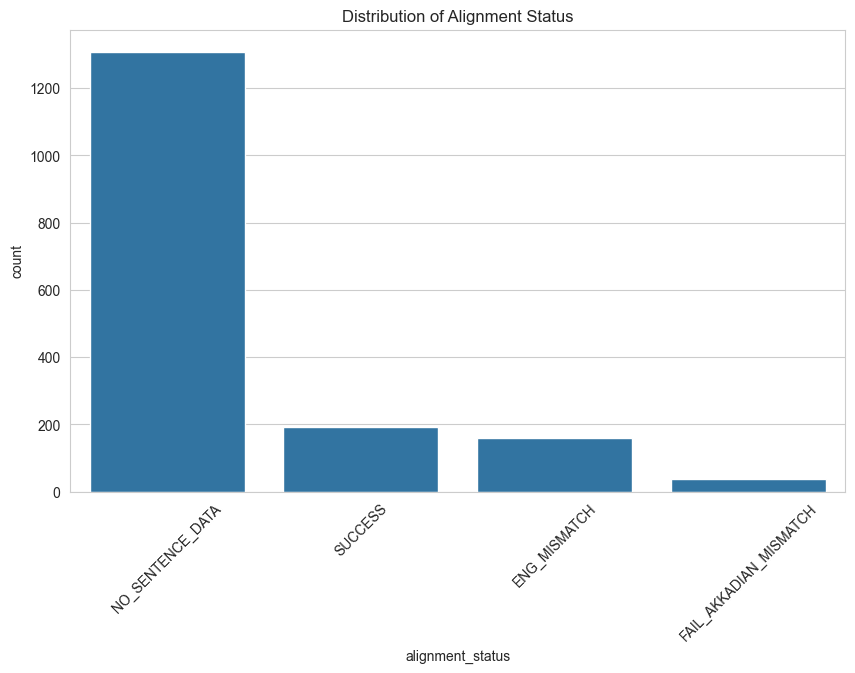

In [5]:
# Bar plot for alignment status
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='alignment_status', order=df['alignment_status'].value_counts().index)
plt.title('Distribution of Alignment Status')
plt.xticks(rotation=45)
plt.show()

## Looking at specific english mismatch examples


In [6]:
import sys
import os

from data_processing.alignment import Aligner

sys.path.append(os.path.abspath("../src"))


log_df = pd.read_csv("../dataset/log_dataset.csv")
train_df = pd.read_csv("../dataset/train.csv")
sentences_oare = pd.read_csv("../dataset/Sentences_Oare_FirstWord_LinNum.csv")

# log_df.head(20)
# just one bad id
bad_id = log_df.loc[log_df['status'] == 'ENG_MISMATCH'].iloc[0]
# train_df.head()

FileNotFoundError: [Errno 2] No such file or directory: '../dataset/log_dataset.csv'

In [7]:
# ENGLISH MISMATCH:
# - Original English Translation text. (train_df['oare_id'] == oare id from mistake))
# - Split sentences (split_preview)
# -  
pd.set_option("display.max_colwidth", None)

train_row = train_df[train_df["id"]==bad_id["oare_id"]]
original_text = train_row["translation"]
# print(original_text.iloc[0])

aligner = Aligner()
split_sents = aligner.split_target_nuclear(original_text.iloc[0])

oare_rows = (
    sentences_oare[sentences_oare["text_uuid"] == bad_id["oare_id"]]
    .sort_values("first_word_number")
    .reset_index(drop=True)
)

oare_sents = oare_rows["translation"].tolist()
print(bad_id["oare_id"])


NameError: name 'bad_id' is not defined

In [286]:
pd.set_option("display.max_colwidth", None)

n = max(len(split_sents), len(oare_sents))

compare_df = pd.DataFrame({
    "i": list(range(n)),
    "your_split": [split_sents[i] if i < len(split_sents) else "" for i in range(n)],
    "oare_translation": [oare_sents[i] if i < len(oare_sents) else "" for i in range(n)],
})

compare_df

,i,your_split,oare_translation
0,0,"Seal of Šu-Illil son of Šu-Kūbum, seal of Ṣilūlu son of Uku.","Seal of Šu-Illil son of Šu-kūbum, seal of Şilūlū son of Uku."
1,1,"When Iddin-abum spoke his will, he gave 10 minas ofדsilver to Šalim-Aššur.","When Iddin-abum spoke his will, he gave 10 minas of silver to Šalim-Aššur."
2,2,He said:,"He said: ""He may take it from the interest on my silver."""
3,3,"He may take it from the interest on my silver.""""",


# Comparing dataset versions

- First iteration: removed duplicate rows
    - 5 extra aligned sentences

In [305]:
df_no_dup = pd.read_csv("../dataset/alignment_datasets/aligned_dataset_1_no_dup.csv")
log_df_no_dup = pd.read_csv("../dataset/alignment_datasets/log_dataset_1_no_dup.csv")

df_aligned_original = pd.read_csv("../dataset/aligned_dataset.csv")

print("\nAlignment status distribution:")
print(df_no_dup['alignment_status'].value_counts())
print("\nLevel distribution:")
print(df_no_dup['level'].value_counts())

print("\nAlignment status distribution:")
print(df_aligned_original['alignment_status'].value_counts())
print("\nLevel distribution:")
print(df_aligned_original['level'].value_counts())


Alignment status distribution:
alignment_status
NO_SENTENCE_DATA          1308
SUCCESS                    196
ENG_MISMATCH               158
FAIL_AKKADIAN_MISMATCH      38
Name: count, dtype: int64

Level distribution:
level
document    1504
sentence     196
Name: count, dtype: int64

Alignment status distribution:
alignment_status
NO_SENTENCE_DATA          1308
SUCCESS                    191
ENG_MISMATCH               159
FAIL_AKKADIAN_MISMATCH      38
Name: count, dtype: int64

Level distribution:
level
document    1505
sentence     191
Name: count, dtype: int64


In [300]:
# Inspecting known example of duplicate sentences: 26f6b7ad-6ef2-4fed-91ec-a35c348823d9	
dup = df_no_dup[df_no_dup["oare_id"]== "26f6b7ad-6ef2-4fed-91ec-a35c348823d9"]
# print(dup)
dup



,oare_id,level,sentence_idx,transliteration,translation,alignment_status,id
262,26f6b7ad-6ef2-4fed-91ec-a35c348823d9,sentence,0.0,ša ki-ma i-dí-a-šùr DUMU ku-bi₄-dí ù ku-la É i-dí-a-bi₄-im a-na ḫu-bu-ul i-dí-a-bi₄-im ik-nu-ku-ma,"The representatives of Iddin-Aššur son of Kūbi-idī and Kula sealed Iddin-abum's house because of Iddin-abum's debt, and they brought out the maid and slave.",SUCCESS,NaN
263,26f6b7ad-6ef2-4fed-91ec-a35c348823d9,sentence,1.0,am-tám ù ÌR uš-té-ṣí-ú,"On the third day Aššur-imittī son of Amur-ilī, Šalim-Aššur's representative, borrowed 17 minas of silver against interest and paid it to cover Iddin-abum's debt to the representatives of Iddin-Aššur and Kula:",SUCCESS,NaN
264,26f6b7ad-6ef2-4fed-91ec-a35c348823d9,sentence,2.0,i-na šál-ší-im ú-mì-im a-šur-i-mì-tí DUMU a-mur-DINGIR ša ki-ma šál-ma-a-šur 17 ma-na KÙ.BABBAR a-na ṣí-ib-tim il₅-qé-ma a-na ḫu-bu-ul i-dí-a-bi₄-im a-na ša ki-ma i-dí-a-šùr ù ku-lá a-lá-ḫu-um DUMU i-dí-sú-en li-ba-a DUMU ú-zu-a ù šu-be-lúm DUMU šál-ma-a-šur iš-qúl-ma É-tí am-tám ù ÌR ša i-dí-a-bi₄-im a-na a-šur-i-mì-tí DUMU a-mur-DINGIR ša ki-ma šál-ma-a-šùr ú-šé-ru,"Alāhum son of Iddin-Suen, Libbaya son of Uzuwa and Šu-Bēlum son of Šalim-Aššur, and they released Iddin-abum's houses, maid and slave to Aššur-imittī son of Amur-ilī, Šalim-Aššur's representative.",SUCCESS,NaN
265,26f6b7ad-6ef2-4fed-91ec-a35c348823d9,sentence,3.0,a-na a-wa-tim a-ni-a-tim kà-ru-um kà-né-eš i-dí-ni-a-tí-ma ṭup-pá-am ša ší-bu-tí-ni IGI GÍR ša a-šùr ni-dí-in,"The Kanesh colony gave us for these proceedings, and we gave a tablet with our testimony before Aššur's dagger.",SUCCESS,NaN
266,26f6b7ad-6ef2-4fed-91ec-a35c348823d9,sentence,4.0,IGI ú-ra-a IGI a-ku-za IGI MAR.TU-ba-ni IGI lá-qé-pì-im IGI i-tur₄-DINGIR,"Witnessed by Uraya, by Akuza, by Amur-rum-bāni, by Lā-qēpum, by Itūr-ilī.",SUCCESS,NaN


In [301]:
# Inspecting known example of duplicate sentences: 26f6b7ad-6ef2-4fed-91ec-a35c348823d9	
dup2= df_aligned_original[df_aligned_original["oare_id"] == "26f6b7ad-6ef2-4fed-91ec-a35c348823d9"]
# print(dup)
dup2

,oare_id,level,sentence_idx,transliteration,translation,alignment_status,id


In [302]:
# Inspecting known example of duplicate sentences: 26f6b7ad-6ef2-4fed-91ec-a35c348823d9	
dup3= train_df[train_df["id"] == "26f6b7ad-6ef2-4fed-91ec-a35c348823d9"]
# print(dup)
dup3

,id,transliteration,translation
243,26f6b7ad-6ef2-4fed-91ec-a35c348823d9,ša ki-ma i-dí-a-šùr DUMU ku-bi₄-dí ù ku-la É i-dí-a-bi₄-im a-na ḫu-bu-ul i-dí-a-bi₄-im ik-nu-ku-ma am-tám ù ÌR uš-té-ṣí-ú i-na šál-ší-im ú-mì-im a-šur-i-mì-tí DUMU a-mur-DINGIR ša ki-ma šál-ma-a-šur 17 ma-na KÙ.BABBAR a-na ṣí-ib-tim il₅-qé-ma a-na ḫu-bu-ul i-dí-a-bi₄-im a-na ša ki-ma i-dí-a-šùr ù ku-lá a-lá-ḫu-um DUMU i-dí-sú-en li-ba-a DUMU ú-zu-a ù šu-be-lúm DUMU šál-ma-a-šur iš-qúl-ma É-tí am-tám ù ÌR ša i-dí-a-bi₄-im a-na a-šur-i-mì-tí DUMU a-mur-DINGIR ša ki-ma šál-ma-a-šùr ú-šé-ru a-na a-wa-tim a-ni-a-tim kà-ru-um kà-né-eš i-dí-ni-a-tí-ma ṭup-pá-am ša ší-bu-tí-ni IGI GÍR ša a-šùr ni-dí-in IGI ú-ra-a IGI a-ku-za IGI MAR.TU-ba-ni IGI lá-qé-pì-im IGI i-tur₄-DINGIR,"The representatives of Iddin-Aššur son of Kūbi-idī and Kula sealed Iddin-abum's house because of Iddin-abum's debt, and they brought out the maid and slave. On the third day Aššur-imittī son of Amur-ilī, Šalim-Aššur's representative, borrowed 17 minas of silver against interest and paid it to cover Iddin-abum's debt to the representatives of Iddin-Aššur and Kula: Alāhum son of Iddin-Suen, Libbaya son of Uzuwa and Šu-Bēlum son of Šalim-Aššur, and they released Iddin-abum's houses, maid and slave to Aššur-imittī son of Amur-ilī, Šalim-Aššur's representative. The Kanesh colony gave us for these proceedings, and we gave a tablet with our testimony before Aššur's dagger. Witnessed by Uraya, by Akuza, by Amur-rum-bāni, by Lā-qēpum, by Itūr-ilī."


In [ ]:
dup_log = log_df_no_dup[log_df_no_dup["oare_id"] == "26f6b7ad-6ef2-4fed-91ec-a35c348823d9"]
dup_log

,oare_id,status,n_oare_rows,n_split_eng,akk_ok,akk_fail_info,split_preview,slice_preview,note
243,26f6b7ad-6ef2-4fed-91ec-a35c348823d9,SUCCESS,5.0,5.0,True,NaN,"[""The representatives of Iddin-Aššur son of Kūbi-idī and Kula sealed Iddin-abum's house because of Iddin-abum's debt, and they brought out the maid and slave."", ""On the third day Aššur-imittī son of Amur-ilī, Šalim-Aššur's representative, borrowed 17 minas of silver against interest and paid it to cover Iddin-abum's debt to the representatives of Iddin-Aššur and Kula:"", ""Alāhum son of Iddin-Suen, Libbaya son of Uzuwa and Šu-Bēlum son of Šalim-Aššur, and they released Iddin-abum's houses, maid and slave to Aššur-imittī son of Amur-ilī, Šalim-Aššur's representative."", ""The Kanesh colony gave us for these proceedings, and we gave a tablet with our testimony before Aššur's dagger."", 'Witnessed by Uraya, by Akuza, by Amur-rum-bāni, by Lā-qēpum, by Itūr-ilī.']","['ša ki-ma i-dí-a-šùr DUMU ku-bi₄-dí ù ku-la É i-dí-a-bi₄-im a-na ḫu-bu-ul i-dí-a-bi₄-im ik-nu-ku-ma', 'am-tám ù ÌR uš-té-ṣí-ú', 'i-na šál-ší-im ú-mì-im a-šur-i-mì-tí DUMU a-mur-DINGIR ša ki-ma šál-ma-a-šur 17 ma-na KÙ.BABBAR a-na ṣí-ib-tim il₅-qé-ma a-na ḫu-bu-ul i-dí-a-bi₄-im a-na ša ki-ma i-dí-a-šùr ù ku-lá a-lá-ḫu-um DUMU i-dí-sú-en li-ba-a DUMU ú-zu-a ù šu-be-lúm DUMU šál-ma-a-šur iš-qúl-ma É-tí am-tám ù ÌR ša i-dí-a-bi₄-im a-na a-šur-i-mì-tí DUMU a-mur-DINGIR ša ki-ma šál-ma-a-šùr ú-šé-ru', 'a-na a-wa-tim a-ni-a-tim kà-ru-um kà-né-eš i-dí-ni-a-tí-ma ṭup-pá-am ša ší-bu-tí-ni IGI GÍR ša a-šùr ni-dí-in', 'IGI ú-ra-a IGI a-ku-za IGI MAR.TU-ba-ni IGI lá-qé-pì-im IGI i-tur₄-DINGIR']",NaN


In [303]:
log_dup = log_df[log_df["oare_id"] == "26f6b7ad-6ef2-4fed-91ec-a35c348823d9"]
log_dup

,oare_id,status,n_oare_rows,n_split_eng,akk_ok,akk_fail_info,split_preview,slice_preview,note
243,26f6b7ad-6ef2-4fed-91ec-a35c348823d9,ENG_MISMATCH,6.0,5.0,True,NaN,"[""The representatives of Iddin-Aššur son of Kūbi-idī and Kula sealed Iddin-abum's house because of Iddin-abum's debt, and they brought out the maid and slave."", ""On the third day Aššur-imittī son of Amur-ilī, Šalim-Aššur's representative, borrowed 17 minas of silver against interest and paid it to cover Iddin-abum's debt to the representatives of Iddin-Aššur and Kula:"", ""Alāhum son of Iddin-Suen, Libbaya son of Uzuwa and Šu-Bēlum son of Šalim-Aššur, and they released Iddin-abum's houses, maid and slave to Aššur-imittī son of Amur-ilī, Šalim-Aššur's representative."", ""The Kanesh colony gave us for these proceedings, and we gave a tablet with our testimony before Aššur's dagger."", 'Witnessed by Uraya, by Akuza, by Amur-rum-bāni, by Lā-qēpum, by Itūr-ilī.']","['', 'ša ki-ma i-dí-a-šùr DUMU ku-bi₄-dí ù ku-la É i-dí-a-bi₄-im a-na ḫu-bu-ul i-dí-a-bi₄-im ik-nu-ku-ma', 'am-tám ù ÌR uš-té-ṣí-ú', 'i-na šál-ší-im ú-mì-im a-šur-i-mì-tí DUMU a-mur-DINGIR ša ki-ma šál-ma-a-šur 17 ma-na KÙ.BABBAR a-na ṣí-ib-tim il₅-qé-ma a-na ḫu-bu-ul i-dí-a-bi₄-im a-na ša ki-ma i-dí-a-šùr ù ku-lá a-lá-ḫu-um DUMU i-dí-sú-en li-ba-a DUMU ú-zu-a ù šu-be-lúm DUMU šál-ma-a-šur iš-qúl-ma É-tí am-tám ù ÌR ša i-dí-a-bi₄-im a-na a-šur-i-mì-tí DUMU a-mur-DINGIR ša ki-ma šál-ma-a-šùr ú-šé-ru', 'a-na a-wa-tim a-ni-a-tim kà-ru-um kà-né-eš i-dí-ni-a-tí-ma ṭup-pá-am ša ší-bu-tí-ni IGI GÍR ša a-šùr ni-dí-in']",NaN


In [304]:
oare_dup = sentences_oare[sentences_oare["text_uuid"] == "26f6b7ad-6ef2-4fed-91ec-a35c348823d9"]
oare_dup

,display_name,text_uuid,sentence_uuid,sentence_obj_in_text,translation,first_word_transcription,first_word_spelling,first_word_number,first_word_obj_in_text,line_number,side,column
5196,Kt 94/k 1051B (AKT 6a 50),26f6b7ad-6ef2-4fed-91ec-a35c348823d9,4ba3c137-e848-4def-aa36-1d6b2c364fd9,2,"The representatives of Iddin-Aššur son of Kūbi-idī and Kula sealed Iddin-abum's house because of Iddin-abum's debt, and they brought out the maid and slave.",ša,ša,1,6,1.0,1,1
5197,Kt 94/k 1051B (AKT 6a 50),26f6b7ad-6ef2-4fed-91ec-a35c348823d9,a3a6a7c6-d91e-4d82-8797-cdece01d6889,3,"The representatives of Iddin-Aššur s. Kūbi-idī and Kula sealed Iddin-abum's house because of Iddin-abum's debt,",ša,ša,1,6,1.0,1,1
5198,Kt 94/k 1051B (AKT 6a 50),26f6b7ad-6ef2-4fed-91ec-a35c348823d9,7a3d6774-6265-401a-8566-cd615c72a36c,25,and they brought out the maid and the slave.,amtam,am-tám,14,27,5.0,1,1
5199,Kt 94/k 1051B (AKT 6a 50),26f6b7ad-6ef2-4fed-91ec-a35c348823d9,968337b3-b0a2-4087-856d-518d8fbbf8e0,31,"On the third day Aššur-imitti son of Amur-ilī, Šalim-Aššur's representative, borrowed 17 minas of silver against interest and paid it to cover Iddin-abum's debt to the representatives of Iddin-Aššur and Kula: Alāhum son of Iddin-Suen, Libbaya son of Uzuwa and Šu-Bēlum son of Šalim-Aššur, and they released Iddin-abum's houses, maid and slave to Aššur-imitti son of Amur-ilī, Šalim-Aššur's representative.",ina,i-na,18,32,6.0,1,1
5200,Kt 94/k 1051B (AKT 6a 50),26f6b7ad-6ef2-4fed-91ec-a35c348823d9,a44f9384-d597-4d28-b4eb-86233d625c87,94,The,ana,a-na,67,95,21.0,1,1
5201,Kt 94/k 1051B (AKT 6a 50),26f6b7ad-6ef2-4fed-91ec-a35c348823d9,cce21777-a61d-4d79-9d40-935cac1b1864,110,"Witnessed by Uraya, by Akuza, by Amur-rum-bāni, by Lā-qēpum, by Itūr-ili.",maḫar,IGI,81,112,26.0,1,1


### Checking overlap in statusses between datasets

## Splitting analysis

### Not splitting (where it should)

case 1
- After the comma (???): the case, and Šalim-Aššur
- Quotes, no space, letters:  the slave?"Šu-Bēlum
- (dot), quotes, space, letter:  and the donkey for you." The Kanesh
Case 140
- debt." Enna


### Splitting, where it shouldnt

Case 0
- Should not split after this comma: He said: "He may take it from the interest on my silver."

Case 3
- Elipsis: Witnessed by Aššur-imittī, by Išme-ilum, by Bi... son of Hannāniya, by Ili-rē'ī son of Šakşum.



### Colons

- Split: 
    -  (splitting correctly) To Kuliya, say, thus says Asānum: | I am still staying etc.
- Don't split:
    - (splitting incorrectly) Without my knowledge he has left for there saying: I am going to Elālī
- General pattern:
    - Short sentence, e.g., 'X said: "blablabla" ' is usually not split (?)
    - **In status correct, there are basicaly NO SENTENCES WITH COLONS, meaning that we are almost always splitting INCORRECTLY** 

### Semicolons
- Until now: don't split (1) vs split (status correct: 1)

### Elipsis
- Some Elipses are split on, others arent. Basically, the sentences with a lot of Elipsis will usually be wrongly split anyway.
- **Try:** split when next sequence of letters start with capital letter, else don't split

### General stuff
- Some data is too different to be splitting (better to keep original)

## Looking at matched sentences

In [ ]:
matched  = log_df.loc[log_df['status'] == 'SUCCESS'].iloc[29] # Adapt index to inspect different tablets

train_row = train_df[train_df["id"]==matched["oare_id"]]
original_text = train_row["translation"]

aligner = Aligner()
split_sents = aligner.split_target_nuclear(original_text.iloc[0])

oare_rows = (
    sentences_oare[sentences_oare["text_uuid"] == matched["oare_id"]]
    .sort_values("first_word_number")
    .reset_index(drop=True)
)

oare_sents = oare_rows["translation"].tolist()

In [242]:
pd.set_option("display.max_colwidth", None)

n = max(len(split_sents), len(oare_sents))

compare_df = pd.DataFrame({
    "i": list(range(n)),
    "your_split": [split_sents[i] if i < len(split_sents) else "" for i in range(n)],
    "oare_translation": [oare_sents[i] if i < len(oare_sents) else "" for i in range(n)],
})

compare_df

,i,your_split,oare_translation
0,0,"1.6666 mina of 'silver dust' Kuliya, son of Ali-abum, Amur-Šamaš, son of Bēlānum, and Ennam-Aššur, son of Šulmim-ša-Aššur, owe to Aššur-mālik, son of Kurara.","1 2/3 mina of 'silver dust' Kuliya, son of Ali-abum, Amur-Šamaš, son of Bēlānum, and Ennam-Aššur, son of Šulmim-ša-Aššur, owe to Aššur-mālik, son of Kurara."
1,1,Per mina they will add 1.5 shekel of silver per month as interest.,Per mina they will add 1 1/2 shekel of silver per month as interest.
2,2,Who of them is financially sound and available is liable for the silver.,Who of them is financially sound and available is liable for the silver.
3,3,"Month XI of the eponymy of Abu-šalim, the trader, son of Ilī-ālum.","Month XI of the eponymy of Abu-šalim, the trader, son of Ilī-ālum."
4,4,"Golden (figurines of) gods, to the number of 20, belonging to Ilī-pī-uṣur, have been deposited as pledge;","Golden (figurines of) gods, to the number of 20, belonging to Ilī-pī-uṣur, have been deposited as pledge; the gods have been put under the seals of the 3 bēru."
5,5,the gods have been put under the seals of the 3 .,"When they received the silver Ṭāb-Aššur, son of Ilī-pī-uṣur, Hudu-bēlī, his slave, and 3 bēru, Liptānum Qardaya, Ennam-Aššur, son of Ikuppi-Aššur, and Amur-Šamaš, son of Pilah-Anum, assisted them."
6,6,"When they received the silver Ṭāb-Aššur, son of Ilī-pī-uṣur, Hudu-bēlī, his slave, and 3, Liptānum Qardaya, Ennam-Aššur, son of Ikuppi-Aššur, and Amur-Šamaš, son of Pilah-Anum, assisted them.","In the presence of Assur-ennam, son of Bur-Suen, of Ennam-Aššur, son of Ennum-Aššur, of Ennam-Aššur, son of Pilah-Ištar."
7,7,"In the presence of Aššur-ennam, son of Bur-Suen, of Ennam-Aššur, son of Ennum-Aššur, of Ennam-Aššur, son of Pilah-Ištar.","1280 minas <of copper> Kuliya, son of Ali-abum, Amur-Šamaš, son of Bēlānum, and Ennam-Aššur, son of Šulmu-ša-Aššur owes to Aššur-mālik, son of Kurara."
8,8,"1280 minas <of copper> Kuliya, son of Ali-abum, Amur-Šamaš, son of Bēlānum, and Ennam-Aššur, son of Šulmu-ša-Aššur owe to Aššur-mālik, son of Kurara.","Month XI of the eponymy of Abu-Šalim, the trader, son of Ilī-ālum."
9,9,"Month XI of the eponymy of Abu-šalim, the trader, son of Ilī-ālum.",Per month the will add an interest of 70 minas per (talent).


In [268]:
matched  = log_df.loc[log_df['status'] == 'FAIL_AKKADIAN_MISMATCH'].iloc[5] # Adapt index to inspect different tablets
train_row = train_df[train_df["id"]==matched["oare_id"]]
original_text = train_row["translation"]
transliteration = train_row["transliteration"]

aligner = Aligner()
split_sents = aligner.split_target_nuclear(original_text.iloc[0])

oare_rows = (
    sentences_oare[sentences_oare["text_uuid"] == matched["oare_id"]]
    .sort_values("first_word_number")
    .reset_index(drop=True)
)

oare_sents = oare_rows["translation"].tolist()
oare_first_words = oare_rows["first_word_spelling"].tolist()
oare_indexes = oare_rows["first_word_number"].tolist()

In [269]:
pd.set_option("display.max_colwidth", None)

n = max(len(split_sents), len(oare_sents))

compare_df = pd.DataFrame({
    "i": list(range(n)),
    "your_split": [split_sents[i] if i < len(split_sents) else "" for i in range(n)],
    "oare_translation": [oare_sents[i] if i < len(oare_sents) else "" for i in range(n)],
    "first_word_spelling": [oare_first_words[i] if i < len(oare_sents) else "" for i in range(n)],
    "first_word_idx": [str(oare_indexes[i]) if i < len(oare_sents) else "" for i in range(n)],
    # "Transliteration": [train_row["transliteration"] if n==0 else "" for i in range(n)]
})
print(transliteration)
print(matched["akk_fail_info"])
compare_df


411    a-na … ù a-lá-ḫi-im qí-bi-ma um-ma en-um-a-šùr-ma a-na a-lá-ḫi-im qí-bi-ma a-dí ša um-me-a-ni ša a-bi-ni tí-ir-tí a-dí ma-lá ù ší-ni-šu i-li-kà-kum-ma nu-za-kà-nim ù a-na … x ša qá-sú-nu iš-ku-nu-ni i-na na-áp-tù ḫa-ra-nim ú x x i-na wa-ar-ki-tim ki-ma ṣú-ḫa-ru iš-tù ša-lá-tù-ar im-qú-tù-ni-ni-ma KÙ.BABBAR mì-ma lá ub-lu-ni-ni ú a-ṣé-er x x x tù-ša-áš-ni-ú x x x x-ni um-me-a-x … (2 broken lines) (2 broken lines) (3 broken lines) ù wa-ar-kà-sà ša ni-ša-me-ú … URUDU i-sà-ri-du-šu-ma a-na KÙ.BABBAR i-tù-ar a-wa-tum iš-tí ma-ma-ḫi-ir i-bi-tí-iq KÙ.BABBAR 1 GÍN ša ú-šé-ṣí-ú i ma-aḫ-ri-šu-nu a-ša-kán URUDU ša ri šu 2 ANŠE.ḪI.A ṣa-lá-mì 10 i-lá-tim ú ú-nu-sú-nu šé-ep-IŠTAR i-ra-dí-a-ku-nu-tí a-ṣé-er x ma-na ša a-ma-kam i-za-zu-ni x 3 GÚ URUDU KI ma-ma-ḫi-ir ša ku-a-tí x SIG₅ ša e-zi-ba-ku-nu-tí-ni [...]
Name: transliteration, dtype: str
{'mismatch_type': 'word_mismatch', 'sentence_row_idx': 2, 'word_index': 34, 'expected': 'ina', 'actual': 'x', 'train_word_raw': 'x', 'guide_word_raw': 

,i,your_split,oare_translation,first_word_spelling,first_word_idx
0,0,To ...,To ... and Ali-ahum from Ennam-Aššur; specifically to Ali-ahum:,a-na,1
1,1,and Ali-ahum from Ennum-Aššur;,"My messages have come to you a couple of times concerning the investors of our father, that we should clear (the matter); also, for ... on which they have laid claim, when the road opens ...",a-dí,11
2,2,specifically to Ali-ahum:,"Later, as the servants arrived from Šalatuwar and did not bring any silver, and in addition to",i-na,35
3,3,"My messages have come to you a couple of times concerning the investors of our father, that we should clear (the matter);","... and its resolution that we shall hear about ... as to the copper, they will pack it for him and it will be exchanged for silver.",ù,53
4,4,"also, for ...",The matter with Man-mahir has been settled.,a-wa-tum,63
5,5,"on which they have laid claim, when the road opens ...","Every shekel of silver that I have produced, I shall place before them.",KÙ.BABBAR,67
6,6,"Later, as the servants arrived from Šalatuwar and did not bring any silver, and in addition to ...","Šēp-Ištar leads the copper ..., 2 black donkeys, 10 bags plus their harness to you.",URUDU,75
7,7,you repeated ...,"In addition to x mina which stand there, 3 talents of copper, owed by Man-mahir, that he left with you ...",a-ṣé-er,88
8,8,investors ...,,,
9,9,and its resolution that we shall hear about..,,,
